<a href="https://colab.research.google.com/github/snjy-r13/DEEP-LEARNING-24BAD407/blob/main/24BAD407_ex_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:

This function and the CIFAR-10 folder discovery logic are specific to loading the CIFAR-10 dataset's binary files. Since we are now using MNIST loaded from CSV, this cell is no longer relevant.

SyntaxError: unterminated string literal (detected at line 3) (3535253224.py, line 3)

### Deprecated: Original Kaggle Directory Listing

This cell was used to list directories in the Kaggle environment for the previous dataset. It is no longer needed as MNIST is loaded from `/content/sample_data/`.

### Deprecated: Original Kaggle Folder and File Listing

This cell was used to explore the specific data folders in the Kaggle environment for the previous dataset. It is no longer needed.

In [ ]:

import pandas as pd

# Load MNIST training data from CSV
mnist_train_df = pd.read_csv('/content/sample_data/mnist_train_small.csv')
x_train = mnist_train_df.iloc[:, 1:].values  # All columns except the first are pixel values
y_train = mnist_train_df.iloc[:, 0].values   # The first column is the label

# Load MNIST test data from CSV
mnist_test_df = pd.read_csv('/content/sample_data/mnist_test.csv')
x_test = mnist_test_df.iloc[:, 1:].values
y_test = mnist_test_df.iloc[:, 0].values

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

In [ ]:
# MNIST images are 28x28 grayscale, so reshape to (num_samples, 28, 28, 1)
# The pixel values are currently flattened (784 features).
# We need to reshape them into a 2D image and add a channel dimension.

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Training image shape:", x_train.shape)
print("Testing image shape:", x_test.shape)

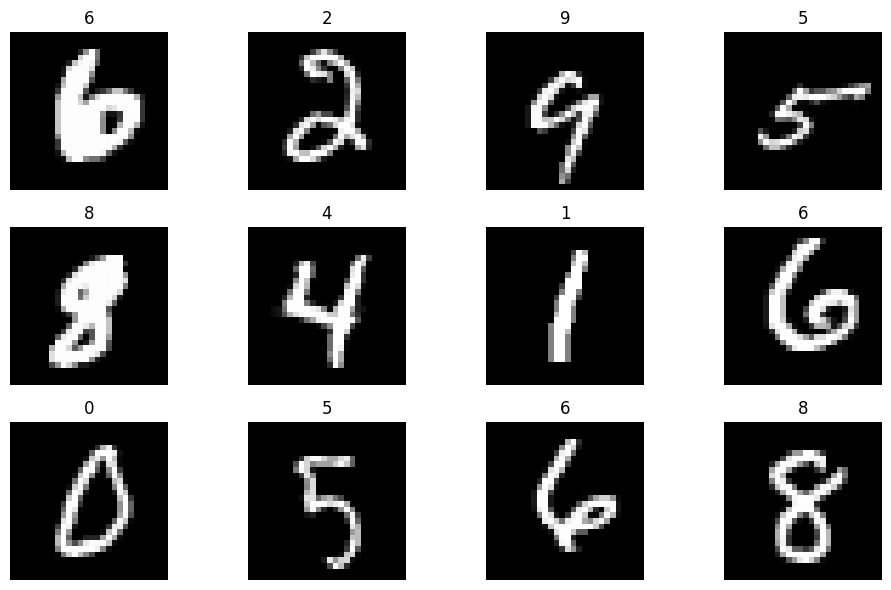

In [ ]:
import matplotlib.pyplot as plt

# MNIST class names are digits 0-9
class_names = [
    "0", "1", "2", "3", "4",
    "5", "6", "7", "8", "9"
]

# Display 12 sample images
plt.figure(figsize=(10, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    # Use cmap='gray' for grayscale MNIST images
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')

    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Normalize pixel values from 0-255 to 0-1

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [ ]:
from sklearn.model_selection import train_test_split

# Use x_train and y_train from the MNIST dataset for splitting
x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.25, # Changed to 25% of the available training data for validation
    random_state=42,
    stratify=y_train
)

print("Training data:", x_train.shape)
print("Training labels:", y_train.shape)

print("Validation data:", x_val.shape)
print("Validation labels:", y_val.shape)

print("Testing data:", x_test.shape) # x_test and y_test should now be MNIST shapes (9999, 28, 28, 1)
print("Testing labels:", y_test.shape)

Training data: (11249, 28, 28, 1)
Training labels: (11249,)
Validation data: (3750, 28, 28, 1)
Validation labels: (3750,)
Testing data: (9999, 28, 28, 1)
Testing labels: (9999,)


In [ ]:
from tensorflow.keras import models, layers

model = models.Sequential([

    # Convolution Layer 1
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    # Max Pooling Layer 1
    layers.MaxPooling2D((2, 2)),

    # Convolution Layer 2
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    # Max Pooling Layer 2
    layers.MaxPooling2D((2, 2)),

    # Convolution Layer 3
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    # Flatten
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(64, activation="relu"),

    # Output Layer - 10 MNIST classes
    layers.Dense(10, activation="softmax")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_val, y_val)
)

Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.8205 - loss: 0.5969 - val_accuracy: 0.9435 - val_loss: 0.1784
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9593 - loss: 0.1310 - val_accuracy: 0.9717 - val_loss: 0.0880
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.9745 - loss: 0.0864 - val_accuracy: 0.9776 - val_loss: 0.0676
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.9782 - loss: 0.0651 - val_accuracy: 0.9760 - val_loss: 0.0806
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.9851 - loss: 0.0455 - val_accuracy: 0.9808 - val_loss: 0.0572
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.9887 - loss: 0.0341 - val_accuracy: 0.9819 - val_loss: 0.0614
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9919 - loss: 0.0280 - val_accuracy: 0.9811 - val_loss: 0.0608
Epoch 8/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.9924 - loss: 0.0228 - val_acc

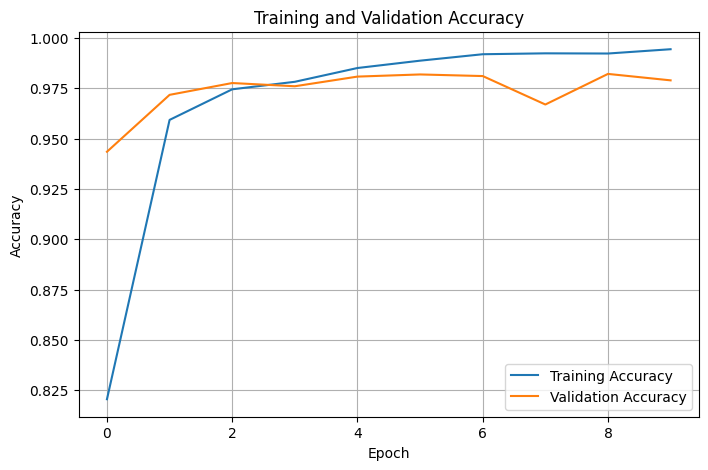

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

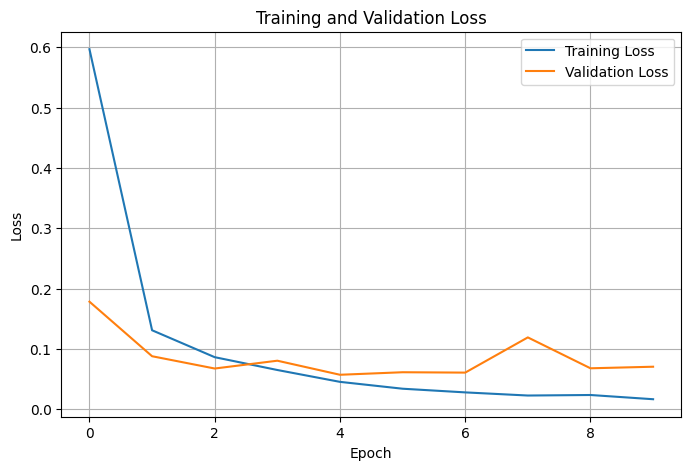

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid()

plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=2
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

313/313 - 2s - 7ms/step - accuracy: 0.9819 - loss: 0.0579
Test Loss: 0.05793175846338272
Test Accuracy: 0.9818981885910034
Test Accuracy (%): 98.18981885910034


In [ ]:
# Generate predictions for test images
predictions = model.predict(x_test)

# Convert probability predictions into class numbers
predicted_classes = np.argmax(predictions, axis=1)

print("Predictions generated successfully!")
print("Actual labels:   ", y_test[:20])
print("Predicted labels:", predicted_classes[:20])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Predictions generated successfully!
Actual labels:    [2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4 9]
Predicted labels: [2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4 9]


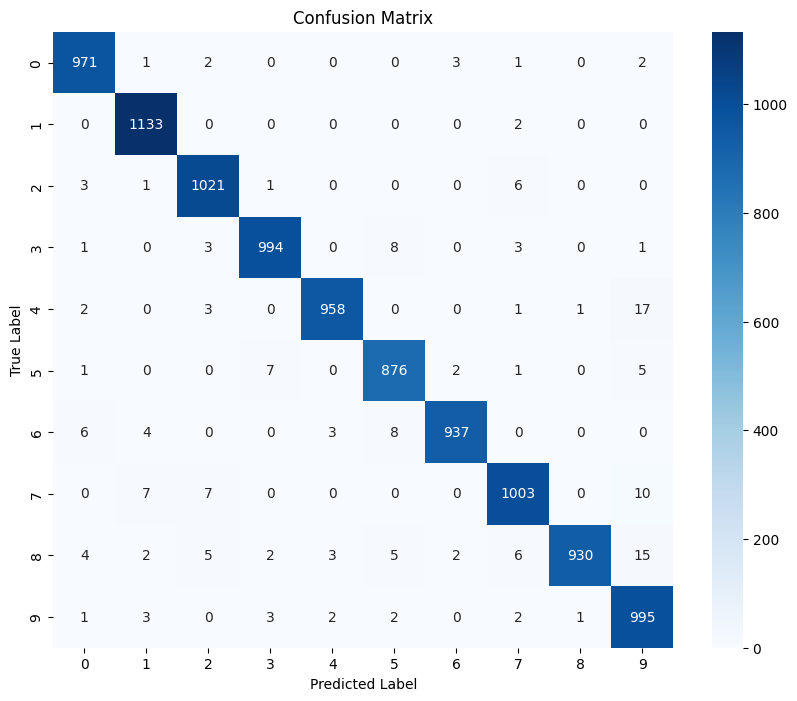

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(
    y_test,
    predicted_classes
)

# Display confusion matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    predicted_classes,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.98      1.00      0.99      1135
           2       0.98      0.99      0.99      1032
           3       0.99      0.98      0.99      1010
           4       0.99      0.98      0.98       982
           5       0.97      0.98      0.98       892
           6       0.99      0.98      0.99       958
           7       0.98      0.98      0.98      1027
           8       1.00      0.95      0.98       974
           9       0.95      0.99      0.97      1009

    accuracy                           0.98      9999
   macro avg       0.98      0.98      0.98      9999
weighted avg       0.98      0.98      0.98      9999



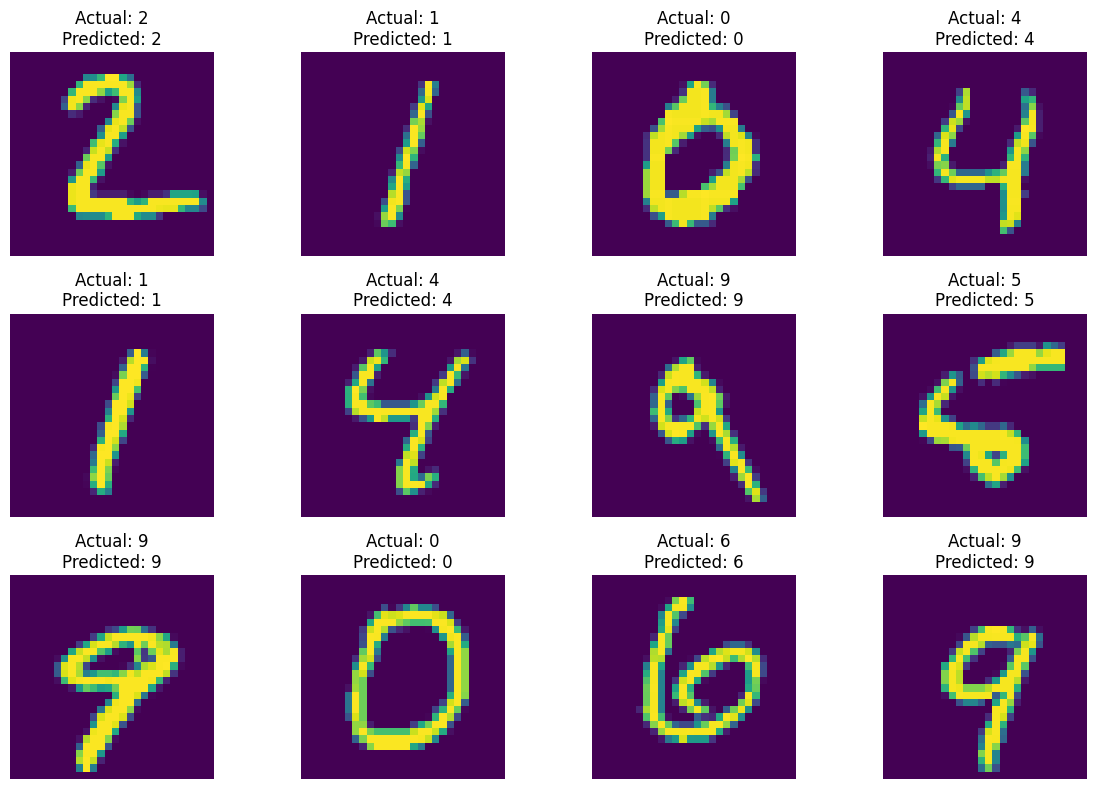

In [ ]:
# Display sample predictions

plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(x_test[i])

    actual = class_names[y_test[i]]
    predicted = class_names[predicted_classes[i]]

    plt.title(
        "Actual: " + actual +
        "\nPredicted: " + predicted
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Find misclassified images

misclassified = np.where(
    predicted_classes != y_test
)[0]

print(
    "Number of misclassified images:",
    len(misclassified)
)

Number of misclassified images: 181


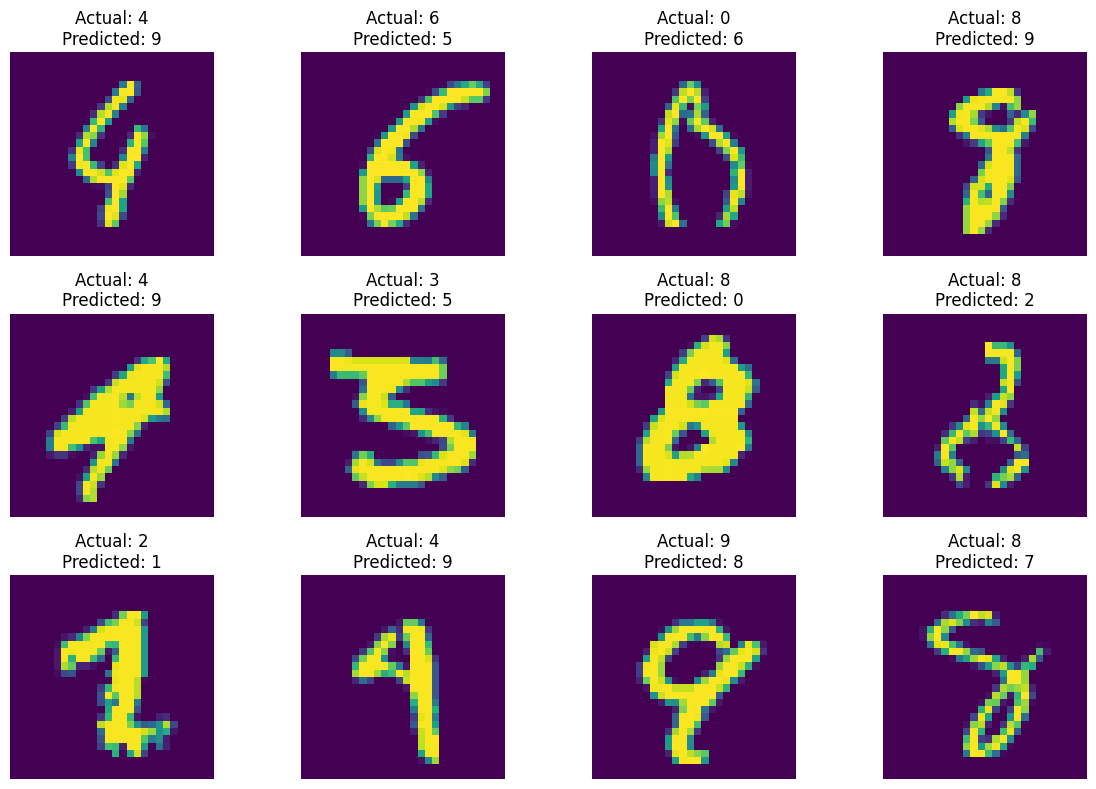

In [ ]:
# Display the first 12 misclassified images

plt.figure(figsize=(12, 8))

for i, index in enumerate(misclassified[:12]):

    plt.subplot(3, 4, i + 1)

    plt.imshow(x_test[index])

    actual = class_names[y_test[index]]
    predicted = class_names[predicted_classes[index]]

    plt.title(
        "Actual: " + actual +
        "\nPredicted: " + predicted
    )

    plt.axis("off")

plt.tight_layout()
plt.show()